<a href="https://colab.research.google.com/github/Laxmi05-01-2006/My-New-Project/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving fifa_world_cup_2026_player_performance.csv to fifa_world_cup_2026_player_performance.csv


In [4]:
df = pd.read_csv("fifa_world_cup_2026_player_performance.csv")


In [5]:
df = df.dropna()


In [6]:
le = LabelEncoder()


In [7]:

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [8]:
target = "tournament_rating"

X = df.drop(columns=[target])
y = df[target]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [11]:
y_pred = model.predict(X_test)


In [12]:

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)


R2 Score : 0.9945279323485948
MAE : 0.1411058608058608
MSE : 0.054886741575091574
RMSE : 0.23427919577950487


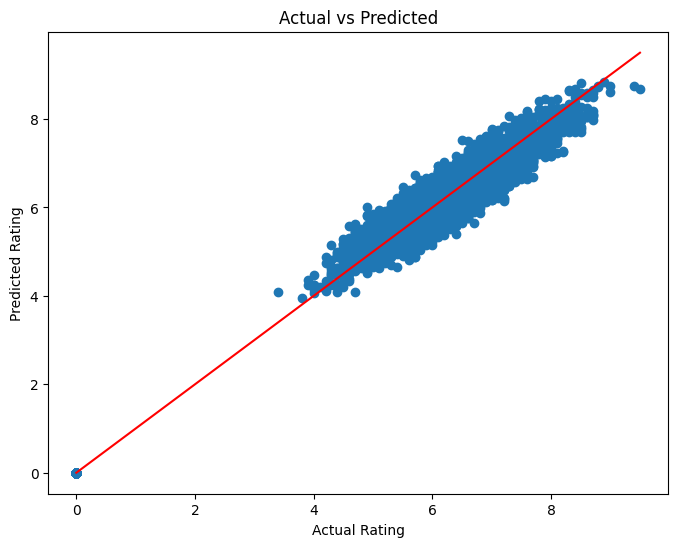

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted")
plt.show()

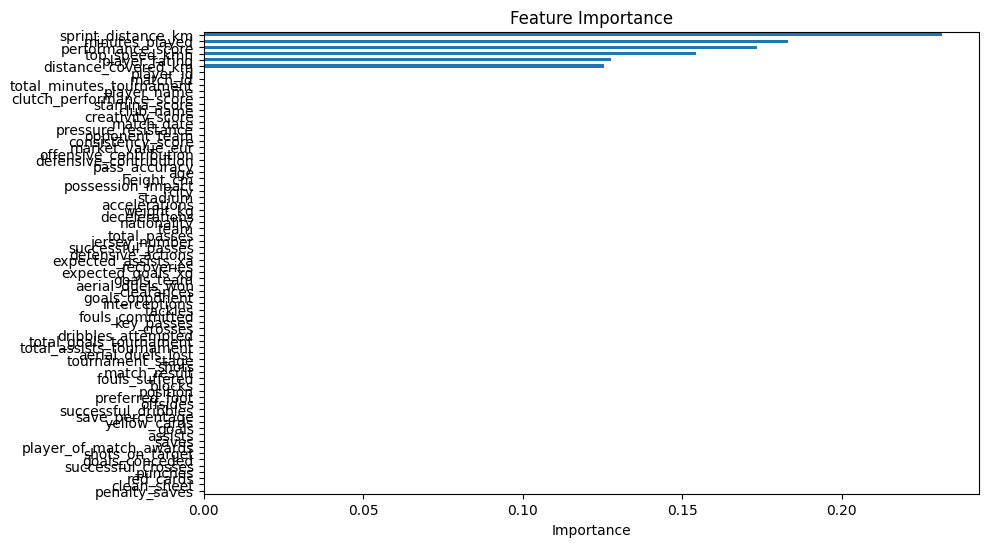

In [14]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

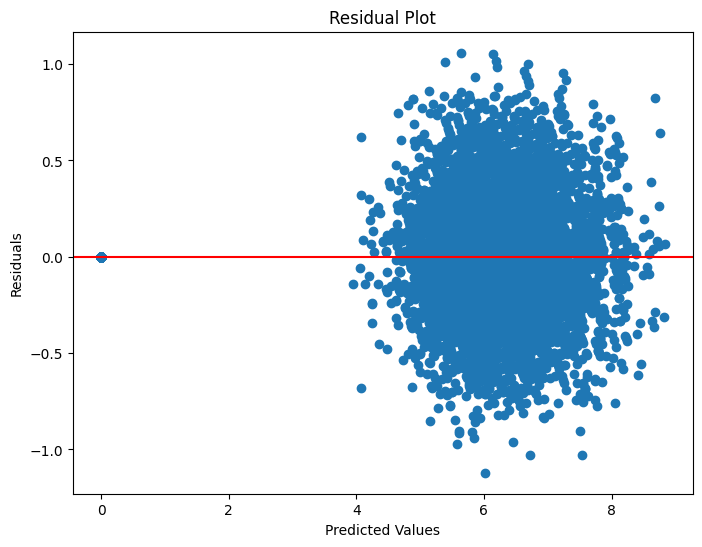

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


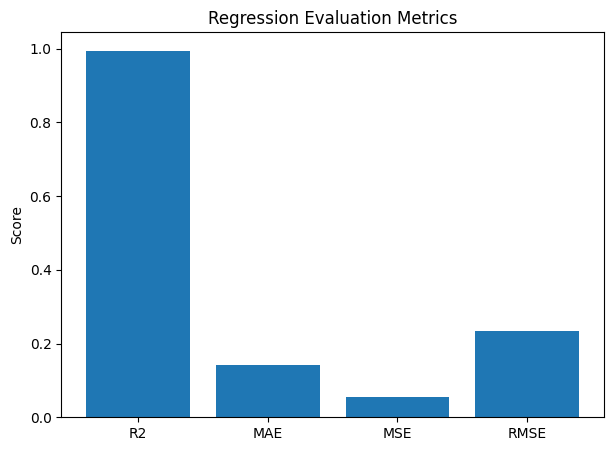

In [16]:
metrics = ['R2', 'MAE', 'MSE', 'RMSE']
values = [r2, mae, mse, rmse]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)

plt.title("Regression Evaluation Metrics")
plt.ylabel("Score")
plt.show()